In [11]:
import os
from collections import defaultdict
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgi

In [2]:
folder = "."

if "a-blue-start.json" not in os.listdir(folder):
    print("File not found. Loading data from xgi-data.")
    H = xgi.load_xgi_data("a-blue-start")
    xgi.write_hif(H, os.path.join(folder, "a-blue-start.json"))
else:
    print("Loading data from local file.")
    H = xgi.read_hif(os.path.join(folder, "a-blue-start.json"))

### Global statistics

Here's how to get the global statistics of the network:

In [8]:
print(f"The number of nodes is {H.num_nodes} and the number of edges is {H.num_edges}.")

The number of nodes is 2003536 and the number of edges is 365842.


### Degree and edge size distributions

We will compute the degrees and edges sizes as `NodeStat` and `EdgeStat` methods.

Node stats and edge stats are quite flexible!

You can
* convert to various formats
    * Numpy array: `asnumpy()`
    * Pandas DataFrame: `aspandas()`
    * List: `aslist()`
    * Dict: `asdict()`
* compute summary statistics (max/min/mean/median/mode/etc/)

In [ ]:
degrees = H.nodes.degree.asnumpy()
edge_sizes = H.edges.size.asnumpy()

In [ ]:
plt.figure()
plt.subplot(121)
plt.hist(degrees, bins=1000)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.yscale("log")
plt.xlim(0, 5e4)

plt.subplot(122)
plt.hist(edge_sizes, bins=1000)
plt.xlabel("Edge Size")
plt.ylabel("Frequency")
plt.yscale("log")
plt.xlim(0, 200)
sns.despine()
plt.show()

In [20]:
H.edges.size.min(), H.edges.size.max(), H.edges.size.mean(), H.edges.size.median()

(0, 4069, 34.72430448116947, 24.0)

In [21]:
H.nodes.degree.min(), H.nodes.degree.max(), H.nodes.degree.mean(), H.nodes.degree.median()

(1, 175159, 6.340594329225929, 1.0)

### Accessing certain edges and nodes

XGI allows us to access nodes and edges by their unique index.

Here, we've listed the first 10 node and edge IDs:

In [26]:
print(
    f"The first 10 node IDs are: {list(H.nodes)[:10]}, and the first 10 edge IDs are: {list(H.edges)[:10]}"
)

The first 10 node IDs are: [7823850, 6987779, 17947103, 18381280, 22016255, 18248237, 9057192, 12679584, 951193, 31517497], and the first 10 edge IDs are: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


We can use these IDs to access the nodes which belong to an edge and the edges to which a node belongs:

In [38]:
print(
    f"Node 7823850 belongs to {H.nodes.memberships(7823850)}, and edge 0 contains the following nodes: {H.edges.members(0)}"
)

Node 7823850 belongs to {0}, and edge 0 contains the following nodes: {18381280, 12679584, 6987779, 4933991, 9057192, 7823850, 17947103, 18248237, 31517497, 951193, 22016255}


We can also get associated attributes of nodes and edges:

In [42]:
print(f"Edge 0: {H.edges[0]}\nNode 7823850: {H.nodes[7823850]}")

Edge 0: {'date-created': '2024-11-11', 'creator-id': 7823850}
Node 7823850: {'date-created': '2024-11-11', 'active': True, 'status': 'normal'}


In [ ]:
number_created = defaultdict(lambda: 0)
starterpack_date_created = []
account_age_at_creation = []
for e in H.edges:
    edge_attrs = H.edges[e]
    n = edge_attrs["creator-id"]
    number_created[n] += 1

    date_created = datetime.fromisoformat(edge_attrs["date-created"])

    try:
        node_attrs = H.nodes[n]
        creator_date_created = datetime.fromisoformat(node_attrs["date-created"])
    except KeyError as e:
        creator_date_created = datetime(1, 1, 1, 0, 0, 0)

    if date_created > datetime(2020, 1, 1, 0, 0, 0):
        starterpack_date_created.append(edge_attrs["date-created"])

    if creator_date_created > datetime(2020, 1, 1, 0, 0, 0):
        # filtering out nans
        account_age_at_creation.append((date_created - creator_date_created).days)
        if account_age_at_creation[-1] < 0:
            print(
                f"The starterpack was created before the user account: {edge_attrs['date-created']} vs. {node_attrs['date-created']}"
            )

The starterpack was created before the user account: 2024-12-27 vs 2024-12-29
The starterpack was created before the user account: 2025-04-05 vs 2025-04-07
The starterpack was created before the user account: 2025-04-05 vs 2025-04-07
The starterpack was created before the user account: 2024-11-15 vs 2024-11-16
The starterpack was created before the user account: 2024-11-16 vs 2024-11-17
The starterpack was created before the user account: 2024-08-31 vs 2024-09-01
The starterpack was created before the user account: 2024-11-17 vs 2024-11-18
The starterpack was created before the user account: 2025-05-09 vs 2025-05-10


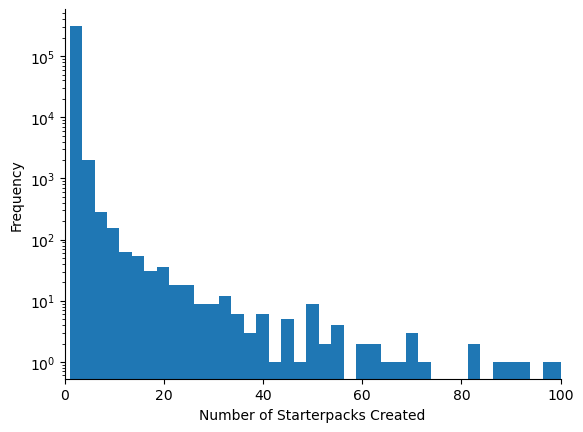

In [9]:
plt.hist(list(number_created.values()), bins=100)
plt.xlabel("Number of Starterpacks Created")
plt.ylabel("Frequency")
plt.yscale("log")
plt.xlim(0, 100)
sns.despine()
plt.show()

How many starter packs did the most prolific creator make?

In [31]:
print(
    f"The maximum number of starterpacks created by a single user is {max(number_created.values())}."
)

The maximum number of starterpacks created by a single user is 252.


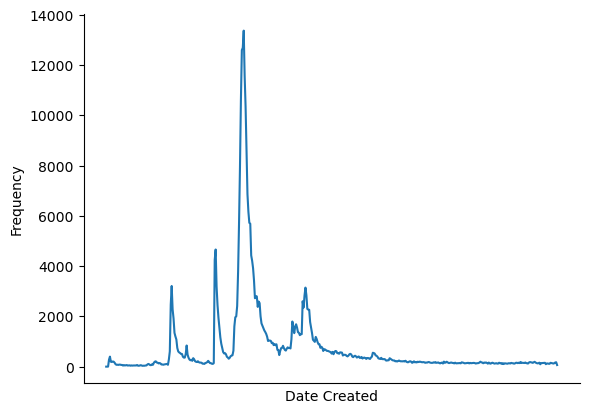

In [13]:
dates, counts = np.unique(starterpack_date_created, return_counts=True)
plt.plot(dates, counts)
plt.xlabel("Date Created")
plt.ylabel("Frequency")
plt.xticks([], [])
sns.despine()
plt.show()

What date had the most starter pack creations?

In [25]:
idx = np.argmax(counts)
dates[idx]

'2024-11-17'

If you want to get the top-10 dates of starter pack creations...

In [30]:
sorted_dates = dates[np.argsort(counts)]
print(f"In descending order of frequency: {", ".join(sorted_dates[-20:][::-1])}")

In descending order of frequency: 2024-11-17, 2024-11-16, 2024-11-15, 2024-11-18, 2024-11-14, 2024-11-19, 2024-11-20, 2024-11-13, 2024-11-21, 2024-11-22, 2024-11-23, 2024-11-12, 2024-11-24, 2024-10-18, 2024-11-25, 2024-10-17, 2024-11-26, 2024-11-27, 2024-11-11, 2024-11-28


What about the typical age of an account when it creates a starter pack?

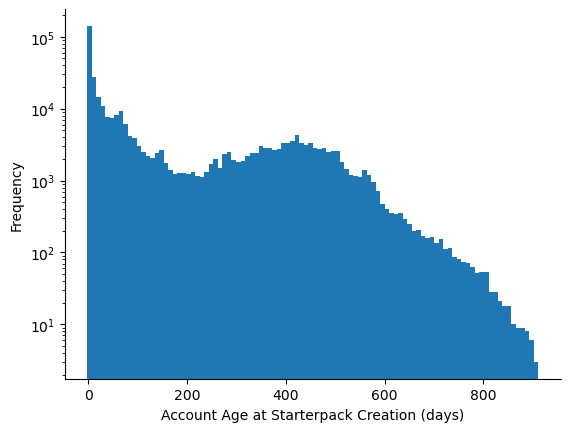

In [ ]:
plt.hist(account_age_at_creation, bins=100)
plt.xlabel("Account Age at Starterpack Creation (days)")
plt.ylabel("Frequency")
plt.yscale("log")
sns.despine()
plt.show()

In [34]:
min(account_age_at_creation), max(account_age_at_creation), np.mean(
    account_age_at_creation
), np.median(account_age_at_creation)

(-2, 911, 131.13858394269062, 23.0)